In [59]:
from matplotlib.ticker import PercentFormatter

import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))

if project_root not in sys.path:
    sys.path.insert(0, project_root)

from scripts.utils import *
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Rescaling, Dropout ,Input, GlobalAveragePooling2D
from keras.callbacks import TensorBoard, ModelCheckpoint, EarlyStopping
from keras.optimizers import SGD, Adam
from keras import layers
from keras.applications import ResNet50

mixed_precision.set_global_policy("mixed_float16")

gpus = tf.config.list_physical_devices("GPU")

if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)




2026-03-15 21:21:53.902205: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-15 21:21:53.973592: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Custom

In [5]:
custom_logs = []

for i in range(1, 16):
    dft = pd.read_csv(f"logs/custom/curves_data_{i}.csv")
    dft["run"] = i
    custom_logs.append(dft)

In [17]:
custom_df = pd.concat(custom_logs)
mean_metrics = custom_df.groupby("Unnamed: 0").mean()

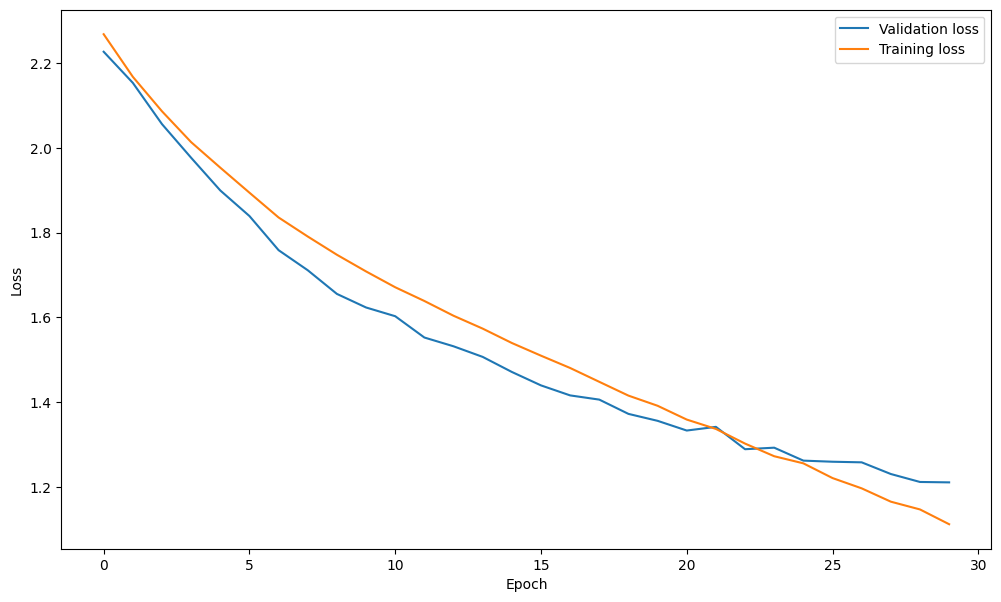

In [35]:
plt.figure(figsize=(12, 7))

ax = sns.lineplot(mean_metrics["val_loss"], label = "Validation loss")
ax2 = sns.lineplot(mean_metrics["loss"], label = "Training loss")

ax.set_ylabel("Loss")
ax.set_xlabel("Epoch")

plt.xticks(fontsize = 10)
plt.yticks(fontsize = 10)

plt.legend(fontsize = 10)
plt.show()

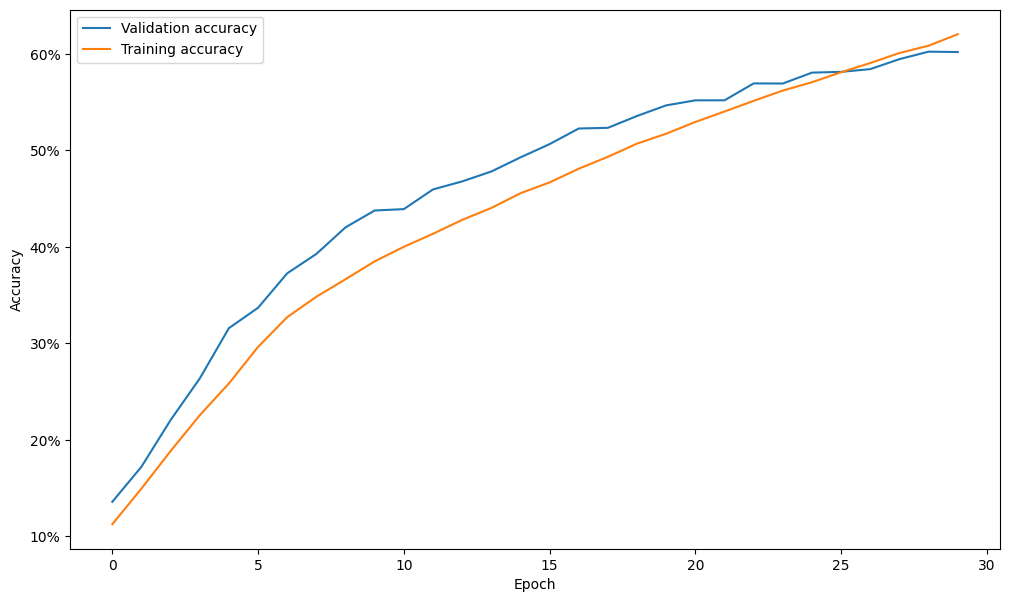

In [44]:
plt.figure(figsize=(12, 7))

ax = sns.lineplot(mean_metrics["val_accuracy"], label = "Validation accuracy")
ax2 = sns.lineplot(mean_metrics["accuracy"], label = "Training accuracy")

ax.set_ylabel("Accuracy")
ax.set_xlabel("Epoch")

ax.yaxis.set_major_formatter(PercentFormatter(1))

plt.xticks(fontsize = 10)
plt.yticks(fontsize = 10)

plt.legend(fontsize = 10)
plt.show()

## MobileNetV2

In [48]:
mobile_logs = []

for i in range(1, 16):
    dft = pd.read_csv(f"logs/mobilenetv2/curves_data_{i}.csv")
    dft["run"] = i
    mobile_logs.append(dft)

In [49]:
mobile_df = pd.concat(mobile_logs)
mean_metrics = mobile_df.groupby("Unnamed: 0").mean()

In [51]:
mean_metrics

,accuracy,loss,val_accuracy,val_loss,run
Unnamed: 0,,,,,
0,0.706537,0.922000,0.813514,0.567408,8.000000
1,0.845871,0.470036,0.842538,0.491075,8.000000
2,0.876062,0.374792,0.848845,0.465140,8.000000
3,0.894756,0.316052,0.853937,0.450153,8.000000
4,0.908286,0.275285,0.855503,0.445278,8.000000
5,0.919804,0.243672,0.859185,0.440275,8.000000
6,0.928936,0.218640,0.860791,0.437451,8.000000
7,0.936209,0.198411,0.860674,0.439679,8.000000
8,0.943067,0.180714,0.859969,0.442566,8.000000


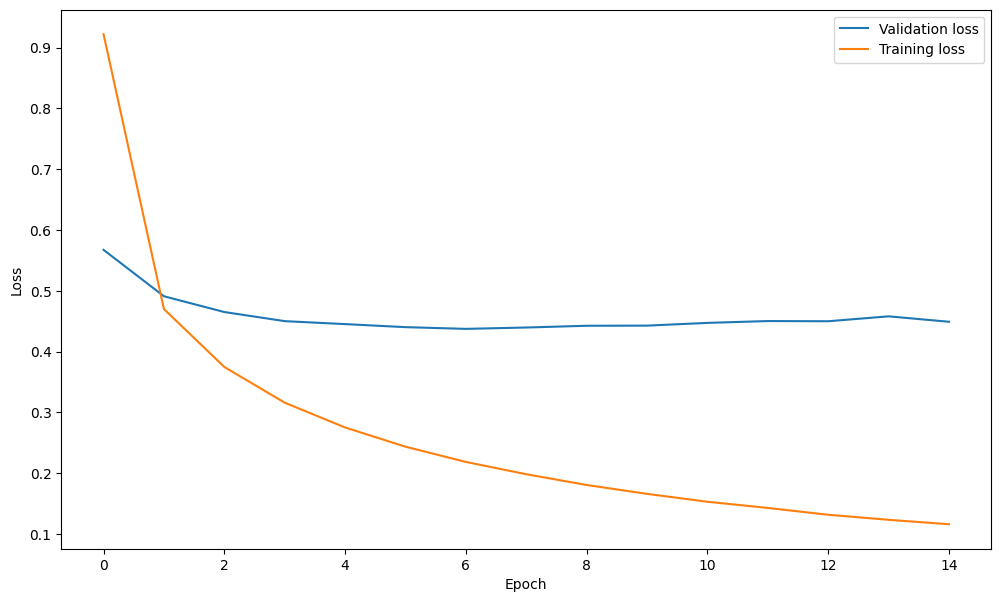

In [57]:
plt.figure(figsize=(12, 7))

ax = sns.lineplot(mean_metrics["val_loss"], label = "Validation loss")
ax2 = sns.lineplot(mean_metrics["loss"], label = "Training loss")

ax.set_ylabel("Loss")
ax.set_xlabel("Epoch")

plt.xticks(fontsize = 10)
plt.yticks(fontsize = 10)

plt.legend(fontsize = 10)
plt.show()

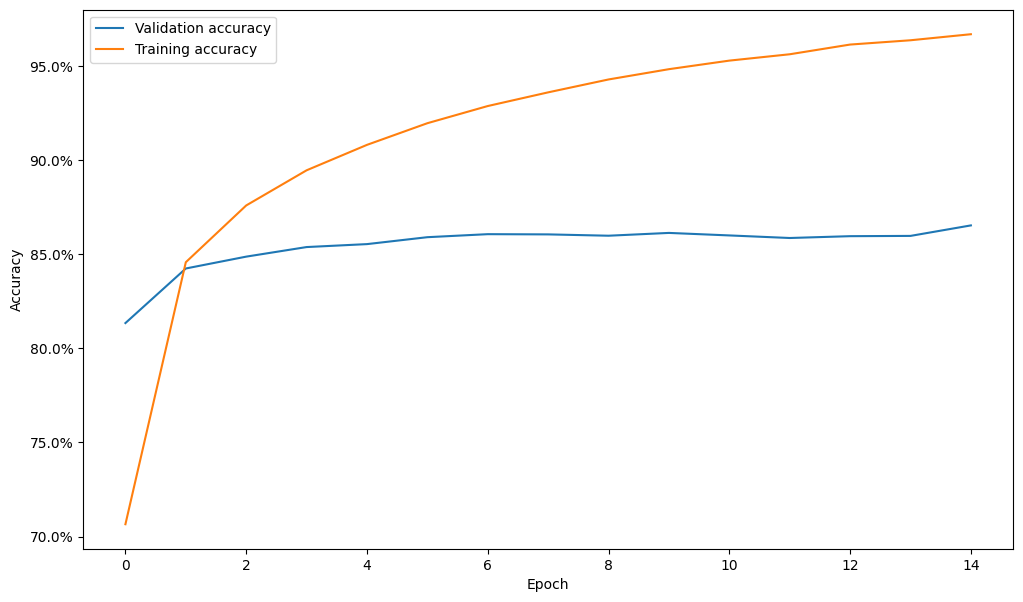

In [58]:
plt.figure(figsize=(12, 7))

ax = sns.lineplot(mean_metrics["val_accuracy"], label = "Validation accuracy")
ax2 = sns.lineplot(mean_metrics["accuracy"], label = "Training accuracy")

ax.set_ylabel("Accuracy")
ax.set_xlabel("Epoch")

ax.yaxis.set_major_formatter(PercentFormatter(1))

plt.xticks(fontsize = 10)
plt.yticks(fontsize = 10)

plt.legend(fontsize = 10)
plt.show()

# Test results

In [ ]:
# directory where images are located
data_dir = "../data/original"

# change depending on which model
image_size = (32, 32)
batch_size = 64

file_paths = []
labels = []

# the name of each folder corresponds to the label of the images within
class_names = os.listdir(data_dir)
class_to_index = {name: i for i, name in enumerate(class_names)}

# for each folder, we'll save the path of each file with its correspondent label
for class_name in class_names:
    class_dir = f"{data_dir}/{class_name}"
    images = sorted(os.listdir(class_dir))
    for img_path in images:
        file_paths.append(class_dir + "/" + str(img_path))
        labels.append(class_to_index[class_name])

# now we have all the paths and labels together
file_paths = np.array(file_paths)


In [61]:
labels = np.array(labels)
dimension = 3

X_train, X_test, y_train, y_test = train_test_split(
    file_paths,
    labels,
    test_size=0.15,
    stratify=labels,
    random_state=42
)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))

X_train_full, y_train_full = load_full_dataset(X_train, y_train)
X_train_full = X_train_full.numpy().astype(int).squeeze()
y_train_labels = np.argmax(y_train_full.numpy(), axis = 1)

X_test_full, y_test_full = load_full_dataset(X_test, y_test)
X_test_full = X_test_full.numpy().astype(int).squeeze()
y_test_labels = np.argmax(y_test_full.numpy(), axis = 1)


I0000 00:00:1773606260.155998   14570 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5563 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9
2026-03-15 21:24:23.861830: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-03-15 21:24:27.698340: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## Custom

In [63]:
def build_custom_model(n_filters = 128, n_neurons = 64, learning_rate = 1e-2, dropout_rate = 0.5, 
                      kernel_size = 3, pool_size = 2, beta_2 = 0.99, sparse = True, momentum = 0.9 ,**kwargs):
    '''
    '''
    
    normalization_layer = Rescaling(1./255)
    
    model = Sequential([
    Input(shape = (image_size[0], image_size[1], dimension)),
    normalization_layer,
    Conv2D(n_filters, kernel_size, activation = "relu", padding = "same"),
    MaxPooling2D(pool_size),
    Conv2D(int(n_filters*2), kernel_size, activation = "relu", padding = "same"),
    MaxPooling2D(pool_size),
    GlobalAveragePooling2D(),
    Dense(n_neurons, activation="relu"),
    Dropout(dropout_rate),
    Dense(int(n_neurons/2), activation="relu"),
    Dropout(dropout_rate),
    Dense(10, activation = "softmax")
                    ])
    
    # for the first model only SGD optimizer is used.
    optimizer = Adam(learning_rate=learning_rate, beta_1=momentum, beta_2=beta_2)
    
    loss = "categorical_crossentropy"
    if sparse:
        loss = "sparse_categorical_crossentropy"
    model.compile(loss = loss,
        optimizer = optimizer,
        metrics = ["accuracy"])
    
    return model

In [ ]:
best_params = load_params("logs/custom/custom_model")
model = build_custom_model(**best_params)
model.fit(X_train_full, y_train_labels,
            epochs=30, verbose = 1,     
            class_weight=class_weights,
            batch_size=batch_size)
model.save('logs/custom/test/custom_model.keras')


2026-03-15 21:31:33.435316: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:382] Garbage collection: deallocate free memory regions (i.e., allocations) so that we can re-allocate a larger region to avoid OOM due to memory fragmentation. If you see this message frequently, you are running near the threshold of the available device memory and re-allocation may incur great performance overhead. You may try smaller batch sizes to observe the performance impact. Set TF_ENABLE_GPU_GARBAGE_COLLECTION=false if you'd like to disable this feature.


Epoch 1/30


2026-03-15 21:31:36.444191: I external/local_xla/xla/service/service.cc:163] XLA service 0x7a019000e100 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-15 21:31:36.444218: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2026-03-15 21:31:36.519342: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-15 21:31:36.896166: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91700
2026-03-15 21:31:37.069796: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-15 21:31:37.

  3/178 ━━━━━━━━━━━━━━━━━━━━ 9s 55ms/step - accuracy: 0.1007 - loss: 2.3735 

I0000 00:00:1773606712.755387   28507 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


177/178 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.0991 - loss: 2.2864

2026-03-15 21:32:02.645667: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-15 21:32:02.645714: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-15 21:32:02.645747: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


178/178 ━━━━━━━━━━━━━━━━━━━━ 34s 95ms/step - accuracy: 0.1135 - loss: 2.2492
Epoch 2/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 10s 55ms/step - accuracy: 0.1729 - loss: 2.1503
Epoch 3/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 10s 54ms/step - accuracy: 0.2181 - loss: 2.0519
Epoch 4/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 10s 54ms/step - accuracy: 0.2638 - loss: 1.9719
Epoch 5/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 10s 54ms/step - accuracy: 0.2949 - loss: 1.9139
Epoch 6/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 10s 54ms/step - accuracy: 0.3153 - loss: 1.8655
Epoch 7/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 10s 54ms/step - accuracy: 0.3330 - loss: 1.8270
Epoch 8/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 10s 54ms/step - accuracy: 0.3545 - loss: 1.7884
Epoch 9/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 10s 54ms/step - accuracy: 0.3576 - loss: 1.7613
Epoch 10/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 10s 54ms/step - accuracy: 0.3594 - loss: 1.7395
Epoch 11/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 10s 54ms/step - accuracy: 0.3900 - loss: 1.6726
Epoch 12/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 

In [69]:
model.evaluate(X_test_full, y_test_labels)

2026-03-15 21:38:02.998601: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-15 21:38:02.998650: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


61/63 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5576 - loss: 1.3172

2026-03-15 21:38:06.386532: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-15 21:38:06.386583: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.5746 - loss: 1.2838


[1.2838133573532104, 0.5746380686759949]

In [70]:
y_test_labels

array([9, 7, 9, ..., 9, 8, 5])

In [77]:
y_pred = np.argmax(model.predict(X_test_full), axis = 1)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


In [80]:
cm = compute_classification_metrics(y_test_labels, y_pred, class_names=class_names)

              precision    recall  f1-score   support

     clothes       0.74      0.72      0.73       298
  biological       0.40      0.94      0.56       122
       trash       0.47      0.50      0.48        74
       paper       0.41      0.50      0.45       207
       glass       0.78      0.46      0.58       300
     battery       0.63      0.77      0.69       122
       shoes       0.61      0.47      0.53       245
       metal       0.53      0.27      0.36       149
     plastic       0.50      0.58      0.54       256
   cardboard       0.71      0.64      0.67       230

    accuracy                           0.57      2003
   macro avg       0.58      0.58      0.56      2003
weighted avg       0.61      0.57      0.57      2003



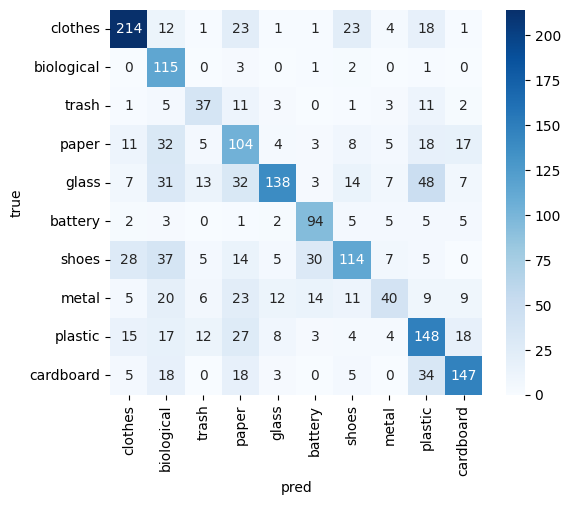

In [81]:
plot_conf_matrix(cm, class_names=class_names)

## MobileNetV2

In [84]:
def build_MobileNetV2(learning_rate = 1e-2, momentum = 0.9, beta_2 = 0.99, **kwargs):
    
    normalization_layer = Rescaling(1./255)
    
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(96, 96, 3),
        include_top=False,
        weights="imagenet"
    )

    base_model.trainable = False

    model = tf.keras.models.Sequential([normalization_layer,
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(10, activation="softmax")
    ])

    optimizer = Adam(learning_rate=learning_rate, beta_1=momentum, beta_2=beta_2)
    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    
    return model


In [85]:
best_params = load_params("logs/mobilenetv2/mobilenetv2_model")
model = build_MobileNetV2(**best_params)

# as seen in validation 15 epochs is enough, because it starts overfitting
model.fit(X_train_full, y_train_labels,
            epochs=15, verbose = 1,     
            class_weight=class_weights,
            batch_size=batch_size)

model.save('logs/mobilenetv2/test/mobile_model.keras')

Epoch 1/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 37s 97ms/step - accuracy: 0.7089 - loss: 0.9217
Epoch 2/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8499 - loss: 0.4661
Epoch 3/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8727 - loss: 0.3750
Epoch 4/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8952 - loss: 0.3184
Epoch 5/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9054 - loss: 0.2808
Epoch 6/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9176 - loss: 0.2477
Epoch 7/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9245 - loss: 0.2241
Epoch 8/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9320 - loss: 0.2044
Epoch 9/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9409 - loss: 0.1852
Epoch 10/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9440 - loss: 0.1733
Epoch 11/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9491 - loss: 0.1604
Epoch 12/15
178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/s

In [88]:
model.evaluate(X_test_full, y_test_labels)

63/63 ━━━━━━━━━━━━━━━━━━━━ 15s 126ms/step - accuracy: 0.8572 - loss: 0.4618


[0.4618390202522278, 0.8572141528129578]

In [86]:
y_pred = np.argmax(model.predict(X_test_full), axis = 1)
cm = compute_classification_metrics(y_test_labels, y_pred, class_names=class_names)

63/63 ━━━━━━━━━━━━━━━━━━━━ 34s 272ms/step
              precision    recall  f1-score   support

     clothes       0.95      0.95      0.95       298
  biological       0.94      0.93      0.94       122
       trash       0.64      0.73      0.68        74
       paper       0.75      0.77      0.76       207
       glass       0.87      0.82      0.85       300
     battery       0.87      0.93      0.90       122
       shoes       0.96      0.94      0.95       245
       metal       0.87      0.79      0.82       149
     plastic       0.74      0.79      0.77       256
   cardboard       0.87      0.84      0.86       230

    accuracy                           0.86      2003
   macro avg       0.85      0.85      0.85      2003
weighted avg       0.86      0.86      0.86      2003



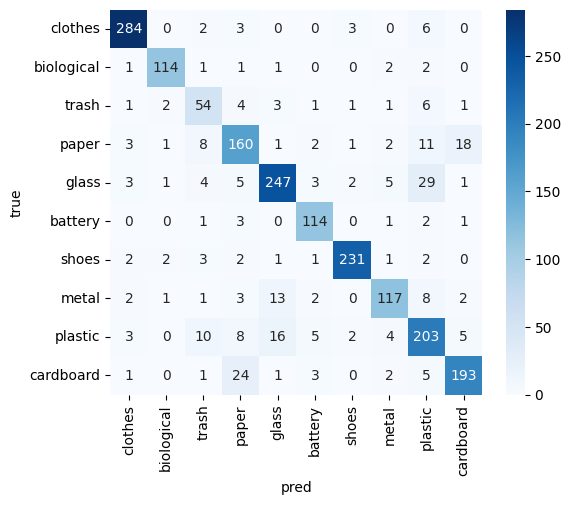

In [87]:
plot_conf_matrix(cm, class_names=class_names)